In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Our 8 ETFs
developed_etfs = ['EWU', 'EWG', 'EWJ', 'EWA']  # UK, Germany, Japan, Australia
emerging_etfs = ['EWZ', 'INDA', 'EWW', 'EZA']   # Brazil, India, Mexico, S.Africa
all_etfs = developed_etfs + emerging_etfs

# Control variables
controls = ['^VIX', 'CL=F', 'DX-Y.NYB', '^TNX']  # VIX, Oil, Dollar Index, 10Y Treasury


# Get ETF data from 2000 to present
etf_data = yf.download(all_etfs, start='2000-01-01', end='2025-12-31', progress=False)


# Get control variables
control_data = yf.download(controls, start='2000-01-01', end='2025-12-31', progress=False)


# US market (S&P 500 for US disruption identification)
us_market = yf.download('^GSPC', start='2000-01-01', end='2025-12-31', progress=False)

print("✅ Data download complete!")

# Let's peek at what we got
print(f"\nETF data shape: {etf_data['Close'].shape}")
print(f"Control data shape: {control_data['Close'].shape}")
print(f"US market data shape: {us_market['Close'].shape}")

print(f"\nETF tickers available: {list(etf_data['Close'].columns)}")
print(f"Date range: {etf_data.index.min()} to {etf_data.index.max()}")


✅ Data download complete!

ETF data shape: (6538, 8)
Control data shape: (6572, 4)
US market data shape: (6538, 1)

ETF tickers available: ['EWA', 'EWG', 'EWJ', 'EWU', 'EWW', 'EWZ', 'EZA', 'INDA']
Date range: 2000-01-03 00:00:00 to 2025-12-30 00:00:00


In [8]:
# Calculate daily returns for all our variables

# ETF returns
etf_returns = etf_data['Close'].pct_change() * 100  # Convert to percentage
etf_returns.dropna(inplace=True)

# US market returns
us_returns = us_market['Close'].pct_change() * 100
us_returns.dropna(inplace=True)
us_returns.name = 'SPX_return'

# Control variable returns/changes
control_returns = control_data['Close'].pct_change() * 100
control_returns.dropna(inplace=True)

print("Quick data preview:")
print(f"ETF returns (last 5 days):")
print(etf_returns.tail())

print(f"\nUS market returns (last 5 days):")
print(us_returns.tail())

print(f"\nControl variables (last 5 days):")
print(control_returns.tail())


Quick data preview:
ETF returns (last 5 days):
Ticker           EWA       EWG       EWJ       EWU       EWW       EWZ  \
Date                                                                     
2025-12-23  1.759086  0.236180  0.845141  0.433886  1.558262  2.195673   
2025-12-24 -0.037581  0.306317 -0.172541  0.227381 -0.126695 -0.315956   
2025-12-26  0.300752  0.187930 -0.037036  0.362976  0.281895  0.570526   
2025-12-29 -0.749628 -0.328261  0.148197 -0.497290 -0.899507 -0.976994   
2025-12-30 -0.264349  0.564577 -0.135643  0.454341 -1.446609  2.158775   

Ticker           EZA      INDA  
Date                            
2025-12-23  1.090275  0.516705  
2025-12-24  0.546444 -0.844507  
2025-12-26  0.557779 -0.314753  
2025-12-29 -2.673869 -0.687219  
2025-12-30  1.169082  0.317932  

US market returns (last 5 days):
Ticker         ^GSPC
Date                
2025-12-23  0.455039
2025-12-24  0.322148
2025-12-26 -0.030436
2025-12-29 -0.349205
2025-12-30 -0.137567

Control variables (la

/var/folders/b0/h_7vtcfj0d9cc_31bc9hxf880000gp/T/ipykernel_39053/3563784339.py:13: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  control_returns = control_data['Close'].pct_change() * 100


In [11]:
# Let's identify major US market disruption days
print("🚨 Identifying major US market disruption events...")

# Fix the filtering and sorting
print("🚨 Identifying major US market disruption events...")

# If us_returns is a DataFrame with one column, we need to specify the column
if isinstance(us_returns, pd.DataFrame):
    us_col = us_returns.columns[0]  # Get the column name (probably '^GSPC')
    us_major_moves = us_returns[abs(us_returns[us_col]) > 8.0][us_col]
    print(f"Found {len(us_major_moves)} days with |US return| > 8%")
    print("\nTop 10 biggest single-day moves:")
    print(us_major_moves.abs().sort_values(ascending=False).head(10))
else:
    # If it's a Series, this should work
    us_major_moves = us_returns[abs(us_returns) > 8.0]
    print(f"Found {len(us_major_moves)} days with |US return| > 8%")
    print("\nTop 10 biggest single-day moves:")
    print(us_major_moves.abs().sort_values(ascending=False).head(10))


# Let's also look at some specific crisis periods
crisis_periods = {
    'Dot-com Crash': ('2000-03-01', '2002-12-31'),
    'Financial Crisis': ('2007-01-01', '2009-12-31'), 
    'COVID Crash': ('2020-02-01', '2020-05-31'),
    'Bank Failures 2023': ('2023-03-01', '2023-05-31')
}


🚨 Identifying major US market disruption events...
🚨 Identifying major US market disruption events...
Found 10 days with |US return| > 8%

Top 10 biggest single-day moves:
Date
2020-03-16    11.984055
2008-10-13    11.580037
2008-10-28    10.789006
2025-04-09     9.515388
2020-03-12     9.511268
2020-03-24     9.382774
2020-03-13     9.287125
2008-10-15     9.034978
2008-12-01     8.929524
2008-09-29     8.806776
Name: ^GSPC, dtype: float64


In [14]:
# Fix the date matching issue
crisis_dates = us_major_moves.index
available_crisis_dates = crisis_dates.intersection(etf_returns.index)

print(f"Crisis dates available in ETF data: {len(available_crisis_dates)} out of {len(crisis_dates)}")
print("International ETF performance on US crisis days:")

# Get the data that exists
crisis_performance = etf_returns.loc[available_crisis_dates].round(2)
print(crisis_performance)


Crisis dates available in ETF data: 5 out of 10
International ETF performance on US crisis days:
Ticker        EWA    EWG   EWJ    EWU    EWW    EWZ    EZA   INDA
Date                                                             
2020-03-12 -13.40 -12.69 -9.80 -10.00  -7.51 -16.64 -14.82 -12.29
2020-03-13  14.15   4.89  3.28   4.25   3.71  17.62   8.12  12.74
2020-03-16 -16.11 -11.73 -6.59 -11.99 -15.25 -23.09 -13.06 -15.44
2020-03-24  12.25  10.76  6.94  11.55   6.33  12.06  10.09   5.51
2025-04-09   9.56   9.03  7.61   5.78   7.91   5.42   9.20   4.19


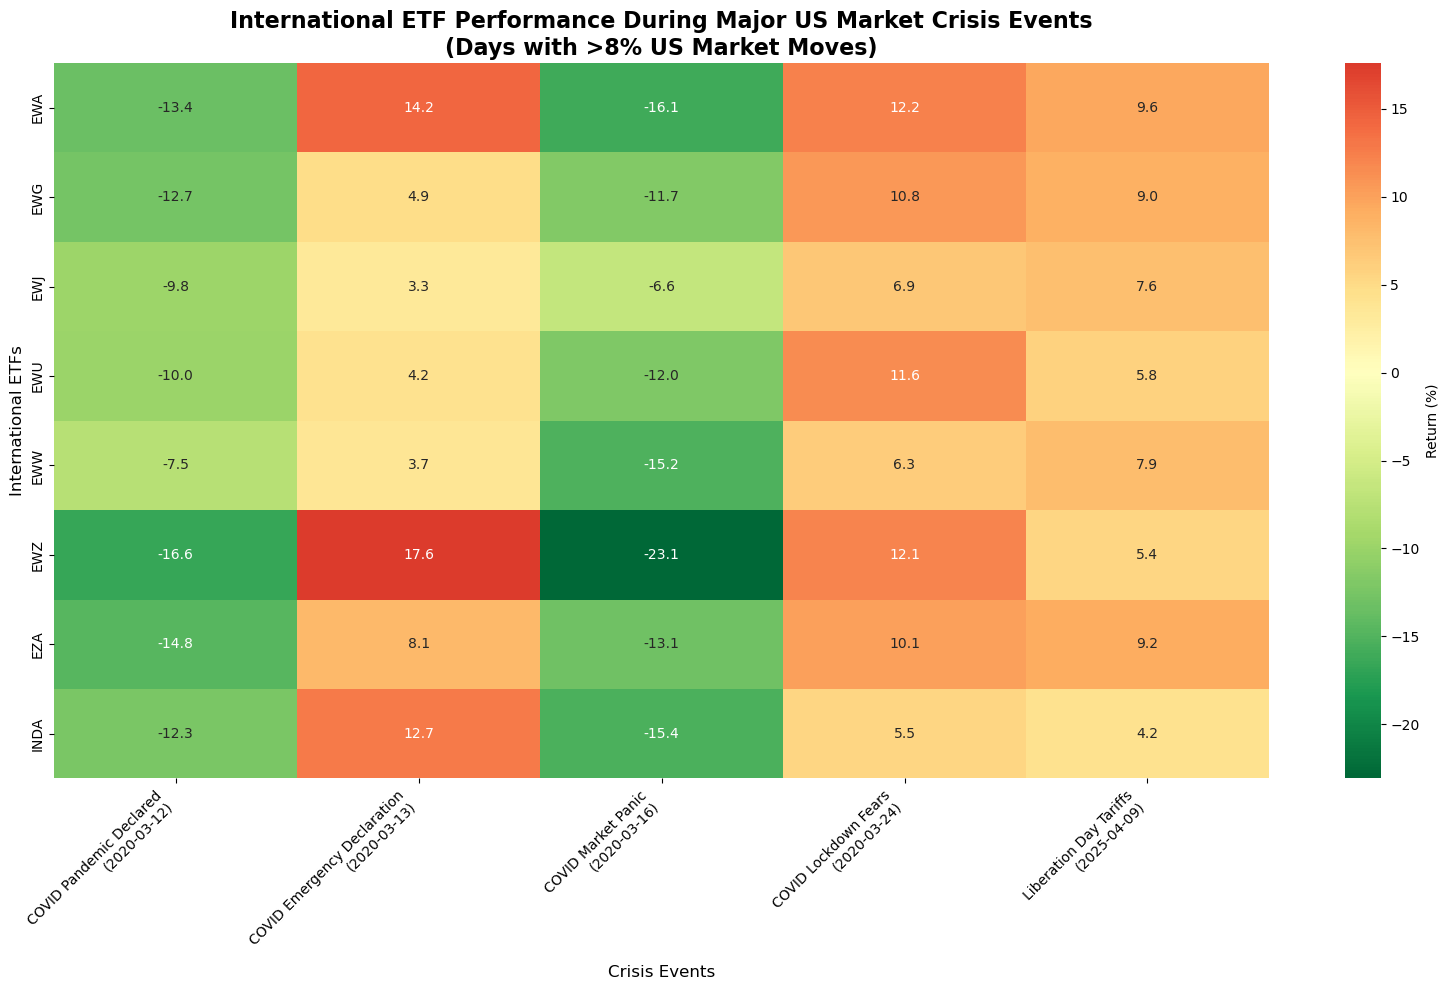

Crisis Events Summary:
COVID Pandemic Declared: US -9.51%
COVID Emergency Declaration: US 9.29%
COVID Market Panic: US -11.98%
COVID Lockdown Fears: US 9.38%
Liberation Day Tariffs: US 9.52%


/var/folders/b0/h_7vtcfj0d9cc_31bc9hxf880000gp/T/ipykernel_39053/2966754964.py:50: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead



In [30]:
# Crisis event dictionary
crisis_events = {
    '2008-09-29': 'Lehman Brothers Collapse',
    '2008-10-13': 'Financial Crisis Peak',
    '2008-10-15': 'Bank Bailout Uncertainty',
    '2008-10-28': 'Credit Crisis Deepens',
    '2008-12-01': 'Recession Confirmation',
    '2020-03-12': 'COVID Pandemic Declared',
    '2020-03-13': 'COVID Emergency Declaration',
    '2020-03-16': 'COVID Market Panic',
    '2020-03-24': 'COVID Lockdown Fears',
    '2025-04-09': 'Liberation Day Tariffs'  
}

# Map crisis dates to event names
available_crisis_dates = crisis_dates.intersection(etf_returns.index)
crisis_performance = etf_returns.loc[available_crisis_dates].round(2)

# Create readable labels
crisis_labels = []
for date in available_crisis_dates:
    date_str = date.strftime('%Y-%m-%d')
    if date_str in crisis_events:
        crisis_labels.append(f"{crisis_events[date_str]}\n({date_str})")
    else:
        crisis_labels.append(date_str)

# Create the enhanced visualization
plt.figure(figsize=(16, 10))
sns.heatmap(crisis_performance.T, 
           annot=True, 
           cmap='RdYlGn_r',
           center=0,
           fmt='.1f',
           cbar_kws={'label': 'Return (%)'},
           xticklabels=crisis_labels)

plt.title('International ETF Performance During Major US Market Crisis Events\n(Days with >8% US Market Moves)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Crisis Events', fontsize=12)
plt.ylabel('International ETFs', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#There is a printing errror
print("Crisis Events Summary:")
for i, date in enumerate(available_crisis_dates):
    date_str = date.strftime('%Y-%m-%d')
    us_move = float(us_returns.loc[date])
    event_name = crisis_events.get(date_str, 'Unknown Event')
    print(f"{event_name}: US {us_move:.2f}%")


In [31]:
import plotly.graph_objects as go

# Create the figure
fig = go.Figure()

# Plot the international ETF returns
for etf in etf_returns.columns:
    fig.add_trace(go.Scatter(x=etf_returns.index, y=etf_returns[etf], mode='lines', name=etf))

# Add vertical lines and annotations for the crisis events
for date, event in crisis_events.items():
    if date in available_crisis_dates:
        fig.add_vline(x=date, line_dash="dash", line_color="red")
        fig.add_annotation(
            x=date,
            y=etf_returns.max().max() + 1,
            text=event,
            showarrow=True,
            arrowhead=1,
            ax=0,
            ay=-20
        )

# Update the layout
fig.update_layout(
    title="International ETF Returns During Major US Market Crisis Events",
    xaxis_title="Date",
    yaxis_title="Return (%)",
    legend_title="ETFs",
    margin=dict(t=100)
)

fig.show()



In [32]:
import statsmodels.api as sm

# Prepare the data
X = us_returns.loc[available_crisis_dates]
y = etf_returns.loc[available_crisis_dates]

# Run the regressions
reg_results = pd.DataFrame(index=etf_returns.columns)

for etf in etf_returns.columns:
    model = sm.OLS(y[etf], sm.add_constant(X)).fit()
    reg_results.loc[etf, 'Intercept'] = model.params[0]
    reg_results.loc[etf, 'US Market Beta'] = model.params[1]
    reg_results.loc[etf, 'R-squared'] = model.rsquared

# Display the results
print("International ETF Regression Results During US Market Crises:")
print(reg_results.round(2))


International ETF Regression Results During US Market Crises:
        Intercept  US Market Beta  R-squared
Ticker                                      
EWA         -0.48            1.32       0.99
EWG         -1.30            1.01       0.96
EWJ         -0.64            0.69       0.91
EWU         -1.29            0.90       0.93
EWW         -2.14            0.88       0.94
EWZ         -3.03            1.57       0.94
EZA         -1.61            1.13       0.98
INDA        -2.47            1.06       0.93


/var/folders/b0/h_7vtcfj0d9cc_31bc9hxf880000gp/T/ipykernel_39053/3234856907.py:12: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/b0/h_7vtcfj0d9cc_31bc9hxf880000gp/T/ipykernel_39053/3234856907.py:13: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/b0/h_7vtcfj0d9cc_31bc9hxf880000gp/T/ipykernel_39053/3234856907.py:12: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/b0/h_7vtcfj0d9cc_31bc9hxf880000gp/T/

In [33]:
print(etf_returns.dtypes)

Ticker
EWA     float64
EWG     float64
EWJ     float64
EWU     float64
EWW     float64
EWZ     float64
EZA     float64
INDA    float64
dtype: object


In [38]:
import statsmodels.api as sm

# Prepare the data
X = pd.DataFrame({'Event': [1 if date in crisis_events else 0 for date in etf_returns.index]})
emerging_flags = [any(col.startswith('EM') for col in etf_returns.columns if col != 'Ticker') for _ in range(len(etf_returns))]
X['Emerging'] = emerging_flags
y = etf_returns.select_dtypes(include='float64')

print(y)
# Run the regression
model = sm.OLS(y,X)
results = model.fit()
results.params
# Display the results
print("International ETF Regression Results During US Market Crises:")
print(model.summary())


Ticker           EWA       EWG       EWJ       EWU       EWW       EWZ  \
Date                                                                     
2012-02-06 -0.624469 -0.401276 -0.310225 -0.400914 -0.360887 -0.205061   
2012-02-07 -0.041910  0.760959  1.037355  0.402528  0.082334  1.115478   
2012-02-08  0.167657  0.533102  0.410694 -0.171807 -0.296131  0.058106   
2012-02-09 -0.083685  0.486093 -0.306761  0.172102  0.857966 -0.159585   
2012-02-10 -2.554441 -2.638560 -1.230775 -1.431821 -1.243258 -2.077895   
...              ...       ...       ...       ...       ...       ...   
2025-12-23  1.759086  0.236180  0.845141  0.433886  1.558262  2.195673   
2025-12-24 -0.037581  0.306317 -0.172541  0.227381 -0.126695 -0.315956   
2025-12-26  0.300752  0.187930 -0.037036  0.362976  0.281895  0.570526   
2025-12-29 -0.749628 -0.328261  0.148197 -0.497290 -0.899507 -0.976994   
2025-12-30 -0.264349  0.564577 -0.135643  0.454341 -1.446609  2.158775   

Ticker           EZA      INDA  
Date

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [42]:
import pandas as pd
import statsmodels.api as sm

# etf_returns: wide DataFrame index=Date, cols=ETF tickers (your posted df)
# crisis_events: set/list of dates where Event=1
# emerging_list: list/boolean mapping of ETFs that are emerging e.g. ['EWZ','EZA', ...]

# 1) long-format panel
y_long = etf_returns.reset_index().melt(id_vars='Date', var_name='ETF', value_name='Return')

# 2) time regressor
y_long['Event'] = y_long['Date'].isin(crisis_events).astype(int)

# 3) ETF-level regressor
y_long['Emerging'] = y_long['ETF'].isin(emerging_etfs).astype(int)

# 4) interaction
y_long['Event_x_Emerging'] = y_long['Event'] * y_long['Emerging']

# 5) optional controls: merge by Date if you have controls (e.g., us_returns)
# y_long = y_long.merge(us_returns[['Market']], left_on='Date', right_index=True)

# 6) run pooled OLS on stacked data
X = sm.add_constant(y_long[['Event', 'Event_x_Emerging']])  # add controls here if available
model = sm.OLS(y_long['Return'].astype(float), X.astype(float)).fit(cov_type='cluster', cov_kwds={'groups': y_long['ETF']})
print(model.summary())


/var/folders/b0/h_7vtcfj0d9cc_31bc9hxf880000gp/T/ipykernel_39053/1658074953.py:12: FutureWarning:

The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.



                            OLS Regression Results                            
Dep. Variable:                 Return   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     8.086
Date:                Sat, 21 Mar 2026   Prob (F-statistic):             0.0152
Time:                        15:59:53   Log-Likelihood:                -51131.
No. Observations:               27968   AIC:                         1.023e+05
Df Residuals:                   27965   BIC:                         1.023e+05
Df Model:                           2                                         
Covariance Type:              cluster                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0305      0.002  

In [48]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

# -------------------------
# Inputs you should have:
# -------------------------
# etf_returns: DataFrame, index=Date (datetime64), columns = ETF tickers (EWA, EWG, EWJ, EWU, EWW, EWZ, EZA, INDA)
# us_returns: Series or DataFrame with US market returns (index=Date), column name like 'US_Return' or '^GSPC'
# control_data: DataFrame with VIX, Oil, Dollar Index, TNX returns or levels (index=Date)
# crisis_events: list or set of pd.Timestamp dates for event days (e.g., Lehman date, COVID bottom, etc.)
# emerging_list: list of ETF tickers tagged as emerging (['EWZ','INDA','EWW','EZA'])

# Example placeholders if you need to create them:
# crisis_events = pd.to_datetime(['2000-03-24','2008-09-15','2020-03-23'])
# emerging_list = ['EWZ','INDA','EWW','EZA']

# -------------------------
# Helper: ensure Date index and align
# -------------------------
def prepare_panel(etf_returns, us_returns, control_data, crisis_events, emerging_list):
    # ensure datetime index
    etf_returns = etf_returns.copy()
    etf_returns.index = pd.to_datetime(etf_returns.index)

    us_returns = us_returns.copy()
    us_returns.index = pd.to_datetime(us_returns.index)
    if isinstance(us_returns, pd.Series):
        us_returns = us_returns.to_frame(name='US_Return')

    control_data = control_data.copy()
    control_data.index = pd.to_datetime(control_data.index)

    # Long format for ETF returns
    y_long = etf_returns.reset_index().melt(id_vars='Date', var_name='ETF', value_name='Return')
    y_long.rename(columns={'index': 'Date'}, inplace=True)
    y_long['Date'] = pd.to_datetime(y_long['Date'])

    # Event dummy
    # robust conversion of events
    if crisis_events is None:
        event_set = set()
    else:
        # allow single string/timestamp or list-like
        if np.isscalar(crisis_events) or isinstance(crisis_events, (pd.Timestamp, str)):
            crisis_events = [crisis_events]
        event_set = set(pd.to_datetime(crisis_events))

    
    y_long['Event'] = y_long['Date'].isin(event_set).astype(int)

    # Emerging flag
    y_long['Emerging'] = y_long['ETF'].isin(emerging_list).astype(int)
    # Interaction
    y_long['Event_x_Emerging'] = y_long['Event'] * y_long['Emerging']

    # Merge controls by Date
    merged = y_long.merge(us_returns.reset_index().rename(columns={'index':'Date'}), on='Date', how='left')
    merged = merged.merge(control_data.reset_index().rename(columns={'index':'Date'}), on='Date', how='left')

    # Forward/backfill any small gaps if necessary (be careful)
    merged = merged.sort_values(['ETF','Date']).reset_index(drop=True)

    return merged

# -------------------------
# Regression functions
# -------------------------
def run_pooled_ols(df, dep='Return', exog_vars=None, add_etf_fe=True, cluster_by='ETF'):
    if exog_vars is None:
        exog_vars = ['Event','Event_x_Emerging']

    X = df[exog_vars].copy()
    X = sm.add_constant(X)
    if add_etf_fe:
        # ETF fixed effects: create dummies and drop first to avoid collinearity
        fe = pd.get_dummies(df['ETF'], prefix='FE', drop_first=True)
        X = pd.concat([X, fe], axis=1)

    y = df[dep].astype(float)
    X = X.astype(float)

    model = sm.OLS(y, X)
    # cluster standard errors by ETF
    res = model.fit(cov_type='cluster', cov_kwds={'groups': df[cluster_by]})
    return res

# -------------------------
# Cumulative returns around event windows
# -------------------------
def compute_event_window_cumreturns(etf_returns, events, window_before=1, window_after=1):
    # etf_returns: wide DataFrame, index=Date
    events = pd.to_datetime(events)
    rows = []
    for e in events:
        start = e - pd.Timedelta(days=window_before)
        end = e + pd.Timedelta(days=window_after)
        window = etf_returns.loc[(etf_returns.index >= start) & (etf_returns.index <= end)]
        if window.empty:
            continue
        # compute cumulative return over window for each ETF (sum of log-returns or product-1 for simple returns)
        # Here assuming etf_returns are simple daily returns (in percent or decimal). Use sum for approx.
        cum = window.sum()  # sum of returns across the window
        tmp = pd.DataFrame({'ETF': cum.index, 'CumReturn': cum.values})
        tmp['EventDate'] = e
        rows.append(tmp)
    if not rows:
        return pd.DataFrame(columns=['EventDate','ETF','CumReturn'])
    out = pd.concat(rows, ignore_index=True)
    return out

# -------------------------
# Placebo test: random non-event dates
# -------------------------
def placebo_test(df, etf_returns, n_placebo=100, window_before=1, window_after=1, seed=0):
    rng = np.random.default_rng(seed)
    all_dates = pd.to_datetime(etf_returns.index.unique())
    # sample dates that are not in events
    sampled = rng.choice(all_dates, size=n_placebo, replace=False)
    # compute cum returns for these sampled dates
    place = compute_event_window_cumreturns(etf_returns, sampled, window_before, window_after)
    return place

# -------------------------
# Main pipeline (example usage)
# -------------------------
def main_pipeline(etf_returns, us_returns, control_data, crisis_events, emerging_list):
    # Build panel
    panel = prepare_panel(etf_returns, us_returns, control_data, crisis_events, emerging_list)

    # Basic pooled regression with ETF FE + controls
    exogs = ['Event', 'Event_x_Emerging', 'US_Return']
    # include other controls if present in control_data (try to detect standard names)
    for col in ['^VIX','VIX','CL=F','DX-Y.NYB','^TNX','TNX','Oil','Dollar','VIX_Close']:
        if col in panel.columns:
            exogs.append(col)

    res = run_pooled_ols(panel, dep='Return', exog_vars=exogs, add_etf_fe=True, cluster_by='ETF')
    print("Pooled OLS with ETF fixed effects (clustered SE by ETF):")
    print(res.summary())

    # Cumulative returns around events (e.g., [-1,+1])
    cum = compute_event_window_cumreturns(etf_returns, crisis_events, window_before=1, window_after=1)
    if not cum.empty:
        # merge ETF-level flags
        cum['Emerging'] = cum['ETF'].isin(emerging_list).astype(int)
        cum['Event'] = 1  # all are event windows
        cum['Event_x_Emerging'] = cum['Event'] * cum['Emerging']
        # Merge controls by EventDate if you want (e.g., US market move on event day)
        # For simplicity, regress CumReturn on Event_x_Emerging (and Emerging if needed)
        Xcum = sm.add_constant(cum[['Event','Event_x_Emerging']].astype(float))
        ycum = cum['CumReturn'].astype(float)
        model_cum = sm.OLS(ycum, Xcum).fit()
        print("\nCumulative returns regression (window [-1,+1]):")
        print(model_cum.summary())
    else:
        print("No cumulative window rows found for given events/window.")

    # Placebo: compute many random windows and run same simple regression to get distribution
    placebo = placebo_test(panel, etf_returns, n_placebo=200, window_before=1, window_after=1, seed=42)
    if not placebo.empty:
        placebo['Emerging'] = placebo['ETF'].isin(emerging_list).astype(int)
        placebo['Event'] = 1
        placebo['Event_x_Emerging'] = placebo['Event'] * placebo['Emerging']
        Xp = sm.add_constant(placebo[['Event','Event_x_Emerging']].astype(float))
        yp = placebo['CumReturn'].astype(float)
        res_placebo = sm.OLS(yp, Xp).fit()
        print("\nPlacebo cumulative returns regression (random dates):")
        print(res_placebo.summary())

    return {'panel_res': res, 'cum_res': model_cum if 'model_cum' in locals() else None, 'placebo_res': res_placebo if 'res_placebo' in locals() else None}

# -------------------------
# Example call (uncomment and set your variables)
# -------------------------
# results = main_pipeline(etf_returns=etf_returns, us_returns=us_returns, control_data=control_data,
#                         crisis_events=crisis_events, emerging_list=emerging_list)


In [57]:
# convert crisis_events (dict) to a list of dates
if isinstance(crisis_events, dict):
    crisis_dates = list(crisis_events.keys())
else:
    crisis_dates = crisis_events

# ensure emerging_list is the list of tickers
emerging_list = emerging_etfs  # your ['EWZ','INDA','EWW','EZA']

# now run
results = main_pipeline(etf_returns=etf_returns,
                        us_returns=us_returns,
                        control_data=control_data,
                        crisis_events=crisis_dates,
                        emerging_list=emerging_list)

# print outputs
print("Panel regression:")
print(results['panel_res'].summary())

if results.get('cum_res') is not None:
    print("\nCumulative-window regression:")
    print(results['cum_res'].summary())

if results.get('placebo_res') is not None:
    print("\nPlacebo regression:")
    print(results['placebo_res'].summary())



MergeError: Not allowed to merge between different levels. (1 levels on the left, 2 on the right)

In [64]:
# extract Close prices (level name 'Price' may be 0)
ctl = control_data.xs('Close', axis=1, level='Price')   # or level=0 if 'Price' not named

# xs returns columns = tickers, but if it's reversed, try:
# ctl = control_data.xs('Close', axis=1, level=0)

# ensure columns are tickers (single level)
ctl.columns = [c for c in ctl.columns]

# convert to returns (simple daily returns)
ctl_returns = ctl.pct_change().dropna()

if isinstance(us_returns, pd.Series):
    us_returns = us_returns.to_frame(name='US_Return')
else:
    us_returns = us_returns.copy()
    # rename the single column to 'US_Return'
    us_returns.columns = ['US_Return']
                          
# pass ctl_returns into pipeline
results = main_pipeline(etf_returns=etf_returns,
                        us_returns=us_returns,
                        control_data=ctl_returns,
                        crisis_events=crisis_dates,
                        emerging_list=emerging_list)

print("Panel regression:")
print(results['panel_res'].summary())

if results.get('cum_res') is not None:
    print("\nCumulative-window regression:")
    print(results['cum_res'].summary())

if results.get('placebo_res') is not None:
    print("\nPlacebo regression:")
    print(results['placebo_res'].summary())



/var/folders/b0/h_7vtcfj0d9cc_31bc9hxf880000gp/T/ipykernel_39053/2326719046.py:11: FutureWarning:

The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



Pooled OLS with ETF fixed effects (clustered SE by ETF):
                            OLS Regression Results                            
Dep. Variable:                 Return   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.467
Method:                 Least Squares   F-statistic:                     441.5
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           1.02e-08
Time:                        16:45:46   Log-Likelihood:                -42321.
No. Observations:               27968   AIC:                         8.467e+04
Df Residuals:                   27953   BIC:                         8.480e+04
Df Model:                          14                                         
Covariance Type:              cluster                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 14, but rank is 7




Placebo cumulative returns regression (random dates):
                            OLS Regression Results                            
Dep. Variable:              CumReturn   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.8133
Date:                Sat, 21 Mar 2026   Prob (F-statistic):              0.367
Time:                        16:45:47   Log-Likelihood:                -3565.6
No. Observations:                1600   AIC:                             7135.
Df Residuals:                    1598   BIC:                             7146.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------